In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree

# Load dataset
df = pd.read_csv(r"C:\Users\devik\Downloads\ML\winequality-red.csv")

# Convert quality into binary classification
df['quality'] = np.where(df['quality'] >= 6, 'Good', 'Bad')

# Define features and target
X = df.drop('quality', axis=1)
y = df['quality']

# Split dataset 70% data → training 30% data → testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,#builds 100 decision trees
    random_state=42
)

# Train model
rf.fit(X_train, y_train) #Model learns patterns from training data.

# Predict
y_pred = rf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
#"Confusion matrix helps evaluate classification performance by showing correct and incorrect predictions for each class."

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8020833333333334
Confusion Matrix:
 [[164  49]
 [ 46 221]]
Classification Report:
               precision    recall  f1-score   support

         Bad       0.78      0.77      0.78       213
        Good       0.82      0.83      0.82       267

    accuracy                           0.80       480
   macro avg       0.80      0.80      0.80       480
weighted avg       0.80      0.80      0.80       480



Plot One Tree

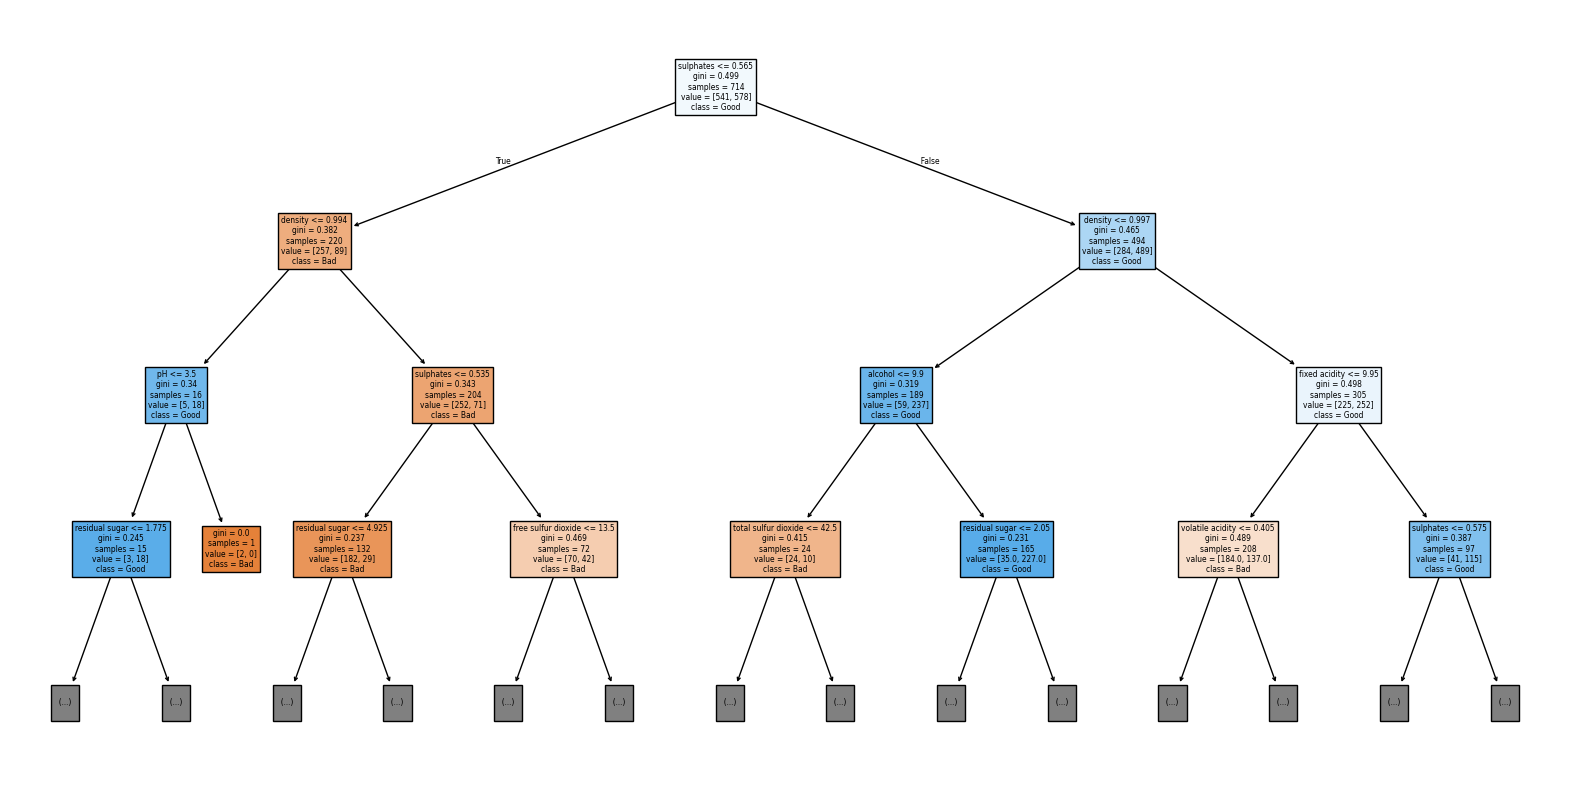

In [5]:
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0],
          feature_names=X.columns,
          class_names=['Bad','Good'],
          filled=True,
          max_depth=3)
plt.show()

Feature importance tells us which independent variable has the strongest impact on predicting wine qualit

alcohol                 0.192218
sulphates               0.129711
volatile acidity        0.105675
total sulfur dioxide    0.101631
density                 0.089659
chlorides               0.074892
fixed acidity           0.066354
pH                      0.064338
citric acid             0.063709
residual sugar          0.057730
free sulfur dioxide     0.054082
dtype: float64


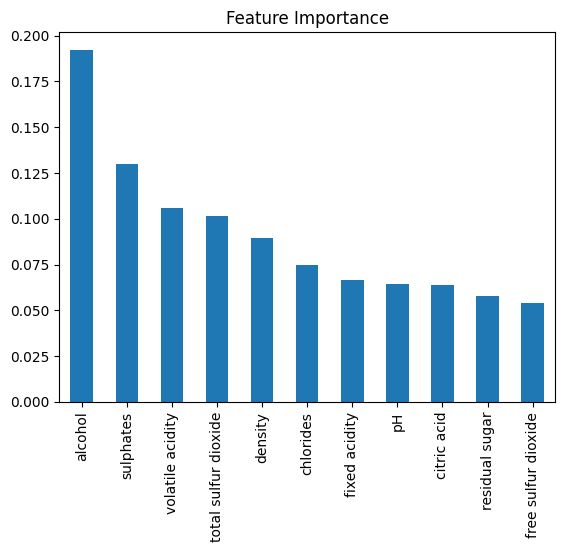

In [6]:
# Feature Importance
importances = rf.feature_importances_
feature_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print(feature_imp)

feature_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()